# 📊 Model Evaluation — XGBoost

Loads the trained model from `models/` and evaluates it on the held-out
`fraudTest` set (the realistic, time-based test). All logic is imported from
the `src/` package — this notebook only visualizes.


In [2]:
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    precision_recall_curve,
)

from fraud_detection.config import MODELS_DIR, TEST_CSV
from fraud_detection.data import load_raw_data
from fraud_detection.features import make_xy

# Load the saved pipeline (preprocess + XGBoost) and the test data
model = joblib.load(MODELS_DIR / "xgboost.joblib")
X_test, y_test = make_xy(load_raw_data(TEST_CSV))

# Predicted fraud probabilities
y_proba = model.predict_proba(X_test)[:, 1]
print(f"Loaded model, scored {len(y_test):,} test transactions")


Loaded model, scored 555,719 test transactions


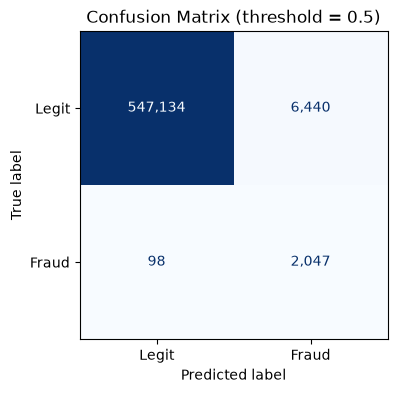

In [3]:
y_pred = (y_proba >= 0.5).astype(int)   # decisions at the default 0.5 threshold

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Legit", "Fraud"],
    cmap="Blues", ax=ax, colorbar=False, values_format=",",
)
ax.set_title("Confusion Matrix (threshold = 0.5)")
plt.show()


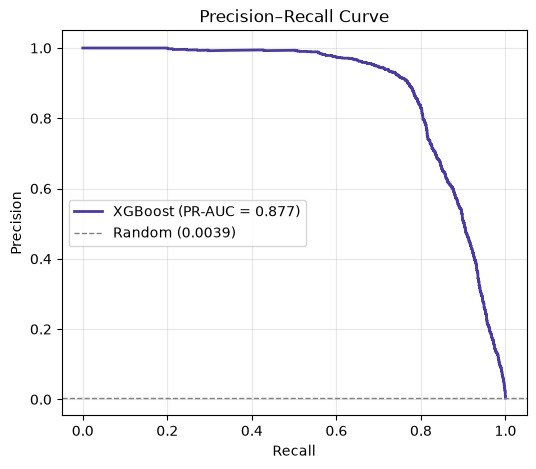

In [4]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
baseline = y_test.mean()   # random-model precision = fraud rate

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall, precision, color="#4a3aa7", lw=2, label=f"XGBoost (PR-AUC = {pr_auc:.3f})")
ax.axhline(baseline, color="gray", ls="--", lw=1, label=f"Random ({baseline:.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall Curve")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


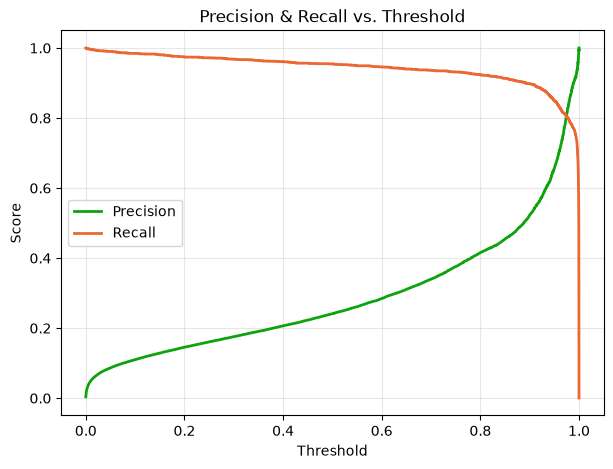

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(thresholds, precision[:-1], color="#0ca30c", lw=2, label="Precision")
ax.plot(thresholds, recall[:-1], color="#eb6834", lw=2, label="Recall")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision & Recall vs. Threshold")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


In [6]:
import numpy as np
import pandas as pd

f1 = 2 * (precision * recall) / (precision + recall + 1e-9)
table = pd.DataFrame({
    "threshold": np.append(thresholds, 1.0),
    "precision": precision,
    "recall": recall,
    "f1": f1,
})

# Print precision/recall at a few candidate thresholds
print(f"{'thresh':>7} {'precision':>10} {'recall':>8} {'f1':>7}")
for t in [0.50, 0.70, 0.80, 0.90, 0.95, 0.99]:
    row = table.iloc[(table["threshold"] - t).abs().argmin()]
    print(f"{row.threshold:>7.2f} {row.precision:>10.3f} {row.recall:>8.3f} {row.f1:>7.3f}")


 thresh  precision   recall      f1
   0.50      0.241    0.954   0.385
   0.70      0.340    0.936   0.499
   0.80      0.415    0.924   0.573
   0.90      0.523    0.898   0.661
   0.95      0.656    0.849   0.740
   0.99      0.904    0.768   0.830


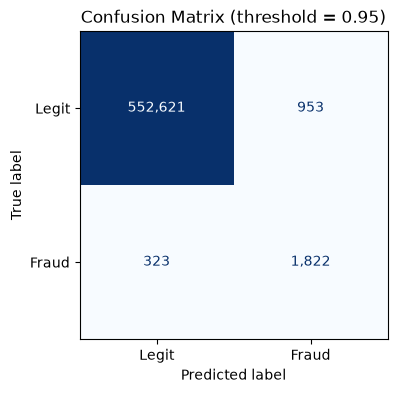

In [7]:
THRESHOLD = 0.95   # our tuned operating point
y_pred_tuned = (y_proba >= THRESHOLD).astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=["Legit", "Fraud"],
    cmap="Blues", ax=ax, colorbar=False, values_format=",",
)
ax.set_title(f"Confusion Matrix (threshold = {THRESHOLD})")
plt.show()


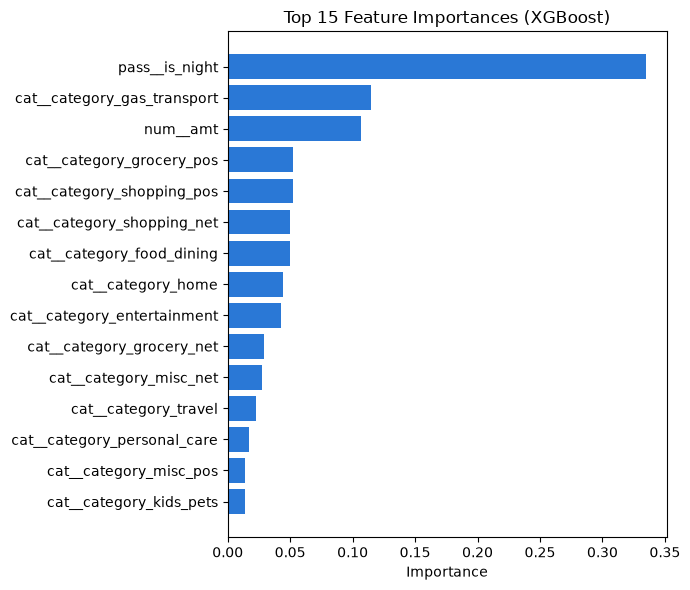

In [9]:
import numpy as np

clf = model.named_steps["clf"]
feature_names = model.named_steps["preprocess"].get_feature_names_out()
importances = clf.feature_importances_

order = np.argsort(importances)[::-1][:15]   # top 15
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(range(len(order)), importances[order][::-1], color="#2a78d6")
ax.set_yticks(range(len(order)))
ax.set_yticklabels([feature_names[i] for i in order][::-1])
ax.set_title("Top 15 Feature Importances (XGBoost)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()
